# **SVD Based Market Regime Detection on S&P 500 Equities**

The project aims to uncover persistent hidden market states such as bullish, bearish, high-volatility, and transitional regimes by analyzing the co-movement structure of equities over time.

In [1]:
import numpy as np
import pandas as pd 
import matplotlib.pyplot as plt
import os
import kagglehub

# **1. Normalizing Returns**

We apply z-score normalization on the returns for each of the companies by finding the mean and standard deviation for the returns of a given company's stock and applying the standard z-score formula:

$Z = \frac{X - \mu}{\sigma}$

In [2]:
df=pd.read_csv('/kaggle/input/datasets/camnugent/sandp500/all_stocks_5yr.csv')
df['date'] = pd.to_datetime(df['date'])
df = df.sort_values(['Name', 'date'])
df['returns'] = df.groupby('Name')['close'].pct_change()
df=df.dropna(subset=['returns'])

mean_returns_by_stock = df.groupby('Name')['returns'].mean()
std_dev_by_stock=df.groupby('Name')['returns'].std()

df['normalized return']=(df.groupby('Name')['returns'].transform(lambda x:(x-x.mean())/x.std()))

# **2. Constructing Covariance Matrix and Performing Eigendecomposition**

We start with our returns matrix that contains daily normalized returns for each company. The covariance matrix helps determine how the stocks move relative to each other. For the element at row i and column j in the normalized return matrix, we can obtain the corresponding element in the Covariance Matrix as:

$$
C_{ij} = \mathrm{Cov}(R_i, R_j)
=
\frac{1}{n-1}
\sum_{t=1}^{n}
(R_{i,t}-\bar{R}_i)(R_{j,t}-\bar{R}_j)
$$

where:
- $C_{ij}$ = element in the $i$-th row and $j$-th column of the covariance matrix  
- $R_{i,t}$ = return of stock $i$ at time $t$  
- $\bar{R}_i$ = mean return of stock $i$  
- $n$ = number of observations/days


On obtaining our covariance matrix, we convert it to a NumPy array for faster linear algebra operations. Finally, we apply eigendecomposition on the covariance matrix. From this, we obtain eigenvectors which are the actual Principal Components themselves, and eigenvalues which denote how much variance each component explains.

In [3]:
returns_mat=df.pivot(
    index='date',
    columns='Name',
    values='returns'
)

cov_mat=returns_mat.cov()
bad = cov_mat.columns[cov_mat.isna().any()]
cov_mat = cov_mat.drop(index=bad, columns=bad)
cov_np = cov_mat.to_numpy()
eigen_val, eigen_vec = np.linalg.eigh(cov_np)
eigen_val.sort()
print(eigen_val)

[-5.68690564e-04 -3.26056064e-04 -2.63233799e-04 -2.19974797e-04
 -1.61343233e-04 -1.44040508e-04 -8.53858147e-05 -7.17291328e-05
 -4.58215853e-05 -3.75853382e-05 -2.36910285e-05 -1.99057294e-05
 -1.02916401e-05 -6.08926843e-06 -5.08702678e-06  3.42356438e-07
  1.40807188e-06  2.61227169e-06  3.86894983e-06  4.51109210e-06
  5.30620780e-06  5.50995033e-06  5.77920190e-06  6.30699178e-06
  6.75471771e-06  7.13102109e-06  7.45701924e-06  7.63005996e-06
  7.74604441e-06  7.94413414e-06  8.09184177e-06  8.23928277e-06
  8.48889628e-06  8.79918997e-06  8.90929634e-06  8.99620346e-06
  9.31055107e-06  9.42091860e-06  9.50472025e-06  9.80685384e-06
  1.01254487e-05  1.02692786e-05  1.03874770e-05  1.06799532e-05
  1.08688030e-05  1.10035523e-05  1.12783874e-05  1.13251853e-05
  1.15220629e-05  1.16287032e-05  1.18245057e-05  1.19460416e-05
  1.22420615e-05  1.24241186e-05  1.26532232e-05  1.27454411e-05
  1.30856846e-05  1.31248136e-05  1.32295047e-05  1.34664220e-05
  1.36453431e-05  1.39423

# **3. Determining Principal Component Count**

We determine the explained variance for each principal component that determines how much the component explains the market movement.

From the explained variance of each component, we can find the explained variance ratio which denotes the fraction of total variance explained per component. This is given as:

$$
\text{Explained Variance Ratio}_i
=
\frac{\lambda_i}{\sum_j \lambda_j}
$$

We can then use this to determine the number of principal components we need for 90% variance, which from plotting the graph can be observed as 196.

In [4]:
eigen_val=np.sort(eigen_val)[::-1]
eigen_val[eigen_val<0]=0

explained_variance_ratio=eigen_val/np.sum(eigen_val)
cumulative_variance=np.cumsum(explained_variance_ratio)
print(cumulative_variance)

[0.26070875 0.30841123 0.33991387 0.36169591 0.37931341 0.39351438
 0.40669685 0.41822486 0.4285555  0.43842022 0.44785249 0.45675772
 0.46555667 0.47393754 0.48210415 0.48995838 0.497398   0.504396
 0.51125701 0.51791609 0.52425876 0.53045021 0.53657577 0.54259022
 0.54837134 0.55382699 0.55921368 0.56441986 0.56947092 0.57441526
 0.57917183 0.5839149  0.58847492 0.59294975 0.59732429 0.60160626
 0.60580743 0.6099344  0.61398704 0.61791595 0.62178811 0.62561187
 0.62937658 0.63304639 0.63661802 0.6401503  0.64360513 0.64700983
 0.65039896 0.65373384 0.65703097 0.6602679  0.66345975 0.66659382
 0.66971037 0.67278884 0.67580375 0.67880294 0.68178259 0.68468919
 0.68759178 0.69039381 0.69316632 0.69590001 0.69860447 0.7012878
 0.70394725 0.70658655 0.70918471 0.71173154 0.71425671 0.71676667
 0.71925492 0.72172534 0.7241855  0.72661883 0.72900653 0.73137493
 0.7337283  0.73601686 0.73829921 0.74057786 0.74281443 0.74503278
 0.74723596 0.74940416 0.75155451 0.75363958 0.7557202  0.7577734

In [5]:
k=np.argmax(cumulative_variance>=0.9)+1
print("No of components for 90% variance:",k)

No of components for 90% variance: 196


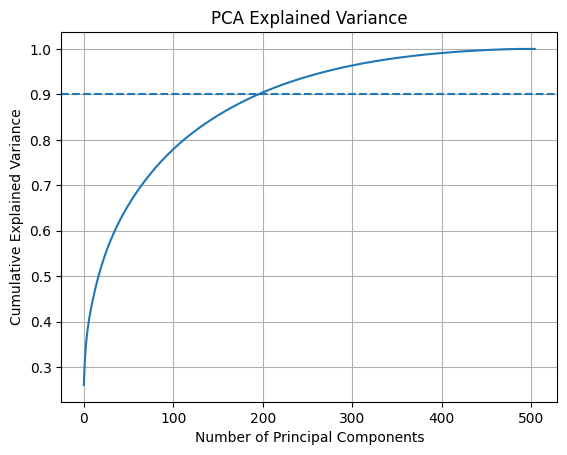

In [6]:
plt.plot(cumulative_variance)
plt.axhline(y=0.90, linestyle='--')
plt.xlabel("Number of Principal Components")
plt.ylabel("Cumulative Explained Variance")
plt.title("PCA Explained Variance")
plt.grid(True)
plt.show()

# **4. Choosing the top k eigenvectors**

From the obtained k-value, we can determine the top k eigenvectors which allow us to obtain the PCA transformed features

In [7]:
idx=np.argsort(eigen_val)[::-1]
eigen_vec=eigen_vec[:, idx]
top_k_vectors=eigen_vec[:, :k]

X=returns_mat.fillna(0).to_numpy()
pca_features=X@top_k_vectors
print(pca_features.shape)

(1258, 196)


# **5. K-Means Market Regimes**

- **Yellow** — Bull / Risk-On Regime  
- **Purple** — Bear / Risk-Off Regime  
- **Teal** — Sideways / Transitional Regime   

In [8]:
from sklearn.cluster import KMeans
kmeans=KMeans(n_clusters=3)
regimes=kmeans.fit_predict(pca_features)

regime_df = pd.DataFrame({
    'date': returns_mat.index,
    'regime': regimes
})

market_return = returns_mat.mean(axis=1)
regime_df['market_return'] = market_return.values
print(
    regime_df.groupby('regime')['market_return'].mean()
)

market_vol = returns_mat.std(axis=1)
regime_df['volatility'] = market_vol.values
print(
    regime_df.groupby('regime')['volatility'].mean()
)

regime
0    0.005657
1    0.001036
2   -0.007227
Name: market_return, dtype: float64
regime
0    0.013619
1    0.012793
2    0.013685
Name: volatility, dtype: float64


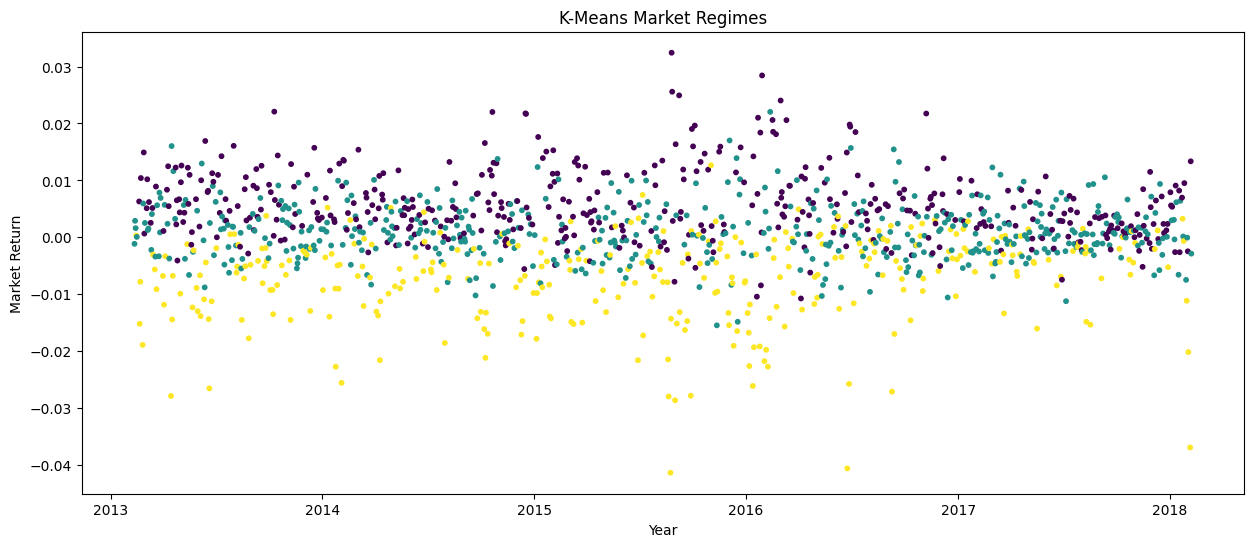

In [9]:
plt.figure(figsize=(15,6))

plt.scatter(
    regime_df['date'],
    regime_df['market_return'],
    c=regime_df['regime'],
    s=10
)

plt.title("K-Means Market Regimes")
plt.ylabel("Market Return")
plt.xlabel("Year")
plt.show()

# **6. Gaussian Mixture Model (GMM) Market Regime**

- **Purple** — Bull / Risk-On Regime  
- **Blue** — Bear / High-Volatility Regime  
- **Yellow** — Neutral / Mild Bull Regime  
- **Teal** — Sideways / Transitional Regime  

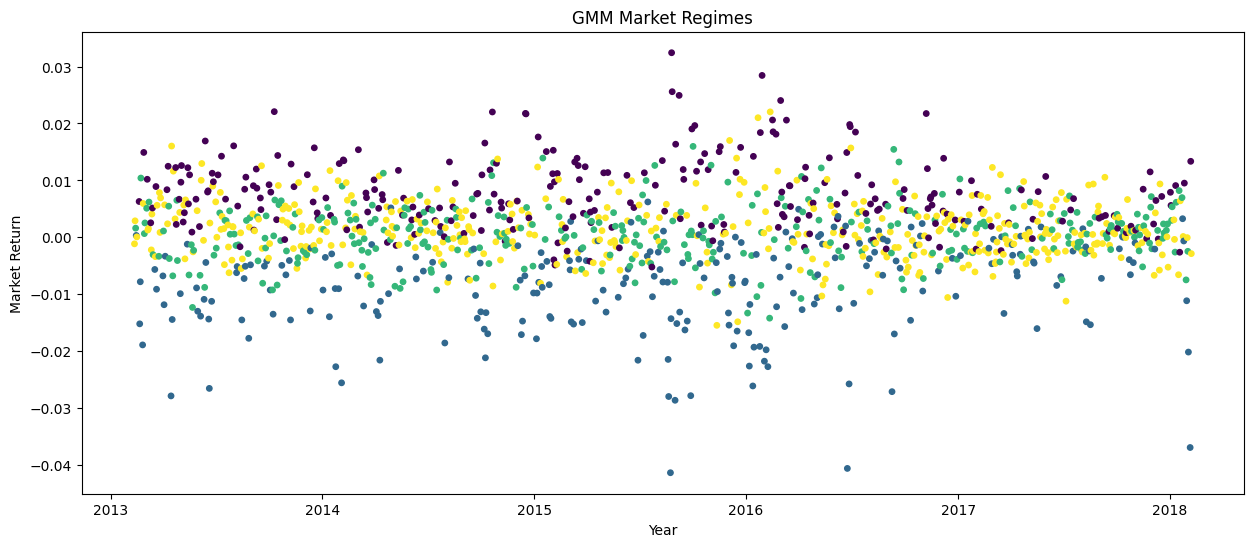

In [10]:
from sklearn.mixture import GaussianMixture

gmm=GaussianMixture(
    n_components=4,
    covariance_type='full',
    random_state=42
)

regimes=gmm.fit_predict(pca_features)

market_return = returns_mat.mean(axis=1)

plt.figure(figsize=(15,6))
plt.scatter(
    returns_mat.index,
    market_return,
    c=regimes,
    cmap='viridis',
    s=15
)

plt.title("GMM Market Regimes")
plt.xlabel("Year")
plt.ylabel("Market Return")
plt.show()

# **7. Hidden Markov Model (HMM) Market Regime**

- **Purple** — Stable / Low-Volatility Regime  
- **Teal** — High-Volatility / Risk-Off Regime  
- **Yellow** — Transitional / Recovery Regime  

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 166.0/166.0 kB 1.3 MB/s eta 0:00:00


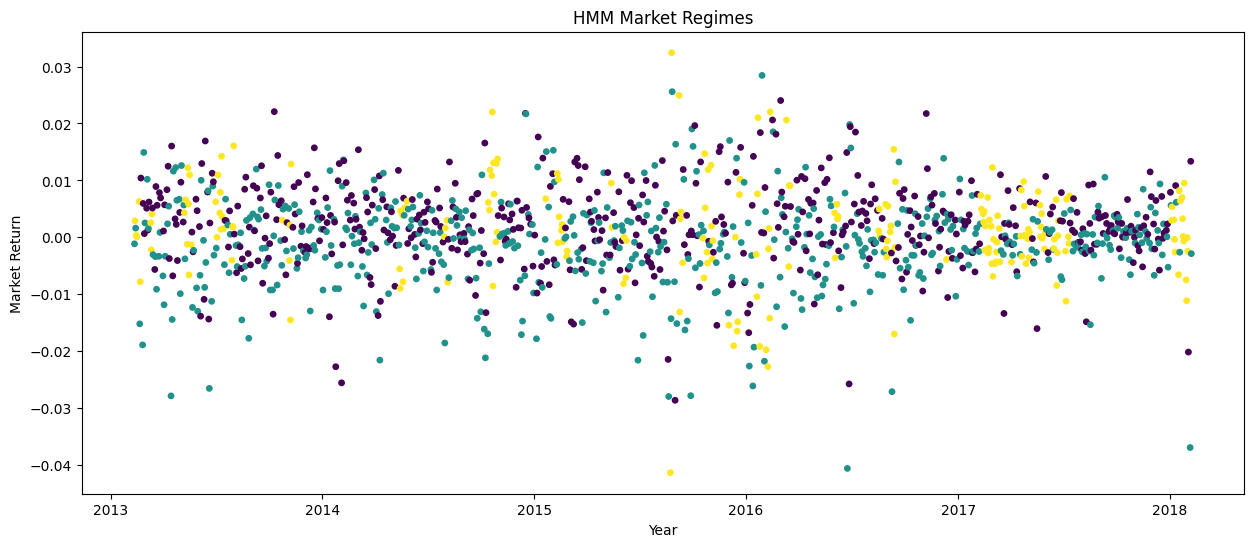

In [11]:
!pip install hmmlearn
from hmmlearn.hmm import GaussianHMM

model = GaussianHMM(
    n_components=3,
    covariance_type='full',
    n_iter=100,
    random_state=42
)

model.fit(pca_features)

regimes = model.predict(pca_features)


plt.figure(figsize=(15,6))

plt.scatter(
    returns_mat.index,
    returns_mat.mean(axis=1),
    c=regimes,
    cmap='viridis',
    s=15
)

plt.title("HMM Market Regimes")
plt.xlabel("Year")
plt.ylabel("Market Return")

plt.show()